In [35]:
import pandas as pd
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel, AdamW, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import numpy as np


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df = pd.read_csv('finaldataset_with_sets.csv') 

# Tokenization
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(text):
    return tokenizer(text, padding='max_length', truncation=True, return_tensors="pt")

df['input_ids'] = df['transcript'].apply(lambda x: tokenize_function(x)['input_ids'].squeeze())
df['attention_mask'] = df['transcript'].apply(lambda x: tokenize_function(x)['attention_mask'].squeeze())

# Dataset preparation
class TextDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        input_ids = self.dataframe.iloc[idx]['input_ids']
        attention_mask = self.dataframe.iloc[idx]['attention_mask']
        label = self.dataframe.iloc[idx]['label']
        return input_ids, attention_mask, label

train_df = df[df['set'] == 'training']
val_df = df[df['set'] == 'validation']

train_dataset = TextDataset(train_df)
val_dataset = TextDataset(val_df)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16)

/opt/anaconda3/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [36]:
class TextClassificationModel(nn.Module):
    def __init__(self, num_classes=5, dropout_rate=0.5):
        super(TextClassificationModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased', output_attentions=True)
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        dropout_output = self.dropout(pooled_output)
        logits = self.fc(dropout_output)
        return logits, outputs.attentions

In [37]:
text_model = TextClassificationModel(num_classes=5, dropout_rate=0.5).to(device)
text_model.load_state_dict(torch.load('text_model_final3.pth'))

A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Pl

<All keys matched successfully>

In [110]:
video_id = "4OL349W7Ufs"
relative_index = val_df.reset_index().index[val_df['video_id'] == video_id].tolist()

if relative_index:
    print(f"The relative position of the video in val_df is: {relative_index[0]}")
else:
    print("Video ID not found in val_df.")


The relative position of the video in val_df is: 65


### Attention-based Explainability

In [39]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_attention(text, model, tokenizer, layer=-1, head=0):
    inputs = tokenizer(text, return_tensors='pt')
    input_ids = inputs['input_ids']
    attention_mask = inputs['attention_mask']
    
    model.eval()  
    with torch.no_grad():
        logits, attentions = model(input_ids=input_ids, attention_mask=attention_mask)
        attention = attentions[layer].squeeze().cpu().numpy()
    
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze().tolist())
    
    # Plot the attention weights
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.heatmap(attention[head], xticklabels=tokens, yticklabels=tokens, square=True, cmap="viridis", ax=ax)
    plt.title(f'Attention Head {head} - Layer {layer}')
    plt.show()

In [40]:
import random
def split_text(text, tokenizer, max_length=512):
    tokens = tokenizer.tokenize(text)
    token_chunks = [tokens[i:i + max_length - 2] for i in range(0, len(tokens), max_length - 2)]
    return [tokenizer.convert_tokens_to_string(chunk) for chunk in token_chunks]

Visualizing attention for the selected example (iloc=60): these pot holders are fantastic for using up leftover yarn they also make great holiday and housewarming


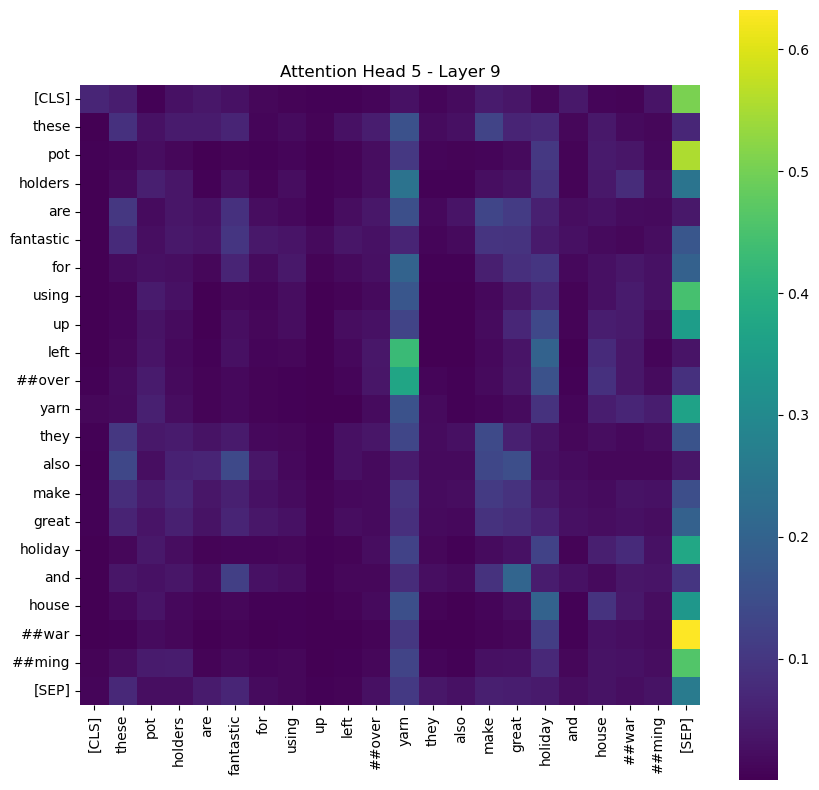

In [118]:
chosen_index = 60

selected_example = val_df.iloc[chosen_index]['transcript'] 

def split_text(text, tokenizer, max_length=512):
    tokens = tokenizer.tokenize(text)
    token_chunks = [tokens[i:i + max_length - 2] for i in range(0, len(tokens), max_length - 2)]
    return [tokenizer.convert_tokens_to_string(chunk) for chunk in token_chunks]


def get_first_n_tokens(text, tokenizer, n=20):
    tokens = tokenizer.tokenize(text)
    truncated_tokens = tokens[:n]
    truncated_text = tokenizer.convert_tokens_to_string(truncated_tokens)
    return truncated_text

truncated_text = get_first_n_tokens(selected_example, tokenizer, n=20)
print(f"Visualizing attention for the selected example (iloc={chosen_index}): {truncated_text}")
visualize_attention(truncated_text, text_model, tokenizer, layer=9, head=5)


### LIME on TEXT model

In [120]:
import lime
from lime.lime_text import LimeTextExplainer
import numpy as np
import torch

def text_model_predict(texts):
    tokenized_inputs = tokenizer(
        texts, padding=True, truncation=True, max_length=512, return_tensors="pt"
    )
    tokenized_inputs = {key: value.to(device) for key, value in tokenized_inputs.items()}

    with torch.no_grad():
        outputs = text_model(input_ids=tokenized_inputs['input_ids'], attention_mask=tokenized_inputs['attention_mask'])
        logits = outputs[0].cpu().numpy() 

    probabilities = torch.nn.functional.softmax(torch.tensor(logits), dim=1).numpy()
    return probabilities

explainer = LimeTextExplainer(class_names=['0-10k', '10k-100k', '100k-500k', '500k-1m', '1m+'])
sample_idx = 60
sample_text = val_df[val_df['set'] == 'validation'].iloc[sample_idx]['transcript']

truncated_text = sample_text[:512]  # Limiting to the first 512 characters
exp = explainer.explain_instance(truncated_text, text_model_predict, num_features=10, num_samples=500)

# Visualize the explanation
exp.show_in_notebook()


### LIME at Late-Fusion Level

In [121]:
import lime
from lime.lime_text import LimeTextExplainer
import numpy as np
import torch

def fused_model_predict(texts):
    tokenized_inputs = tokenizer(texts, return_tensors='pt', padding=True, truncation=True, max_length=512)
    tokenized_inputs = {key: value.to(device) for key, value in tokenized_inputs.items()}
    
    with torch.no_grad():
        # Get text model outputs
        text_outputs = text_model(input_ids=tokenized_inputs['input_ids'], attention_mask=tokenized_inputs['attention_mask'])
        text_logits = text_outputs[0].cpu().numpy() 
        visual_logits = np.zeros_like(text_logits)  
        # Perform late fusion by averaging text and visual logits
        fused_logits = (text_logits + visual_logits) / 2
    
    # Apply softmax to get probabilities
    probabilities = torch.nn.functional.softmax(torch.tensor(fused_logits), dim=1).numpy()
    return probabilities

explainer = LimeTextExplainer(class_names=['0-10k', '10k-100k', '100k-500k', '500k-1m', '1m+'])
sample_text = val_df['transcript'].iloc[60]  
truncated_text = sample_text[:512] 

exp = explainer.explain_instance(truncated_text, fused_model_predict, num_features=10, num_samples=500)

exp.show_in_notebook()

### LIME on Visual Logits

In [69]:
def get_true_class(video_id):
    match = df[df['video_id'] == video_id]
    if not match.empty:
        return match['label'].values[0]
    else:
        raise ValueError(f"Video ID {video_id} not found in the dataset.")

video_id = '4OL349W7Ufs'
true_class = get_true_class(video_id)
true_class

0

In [96]:
# Load an image from your validation set
sample_image = plt.imread('validation_frames/4OL349W7Ufs/frame_0850.jpg')

  0%|          | 0/1000 [00:00<?, ?it/s]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


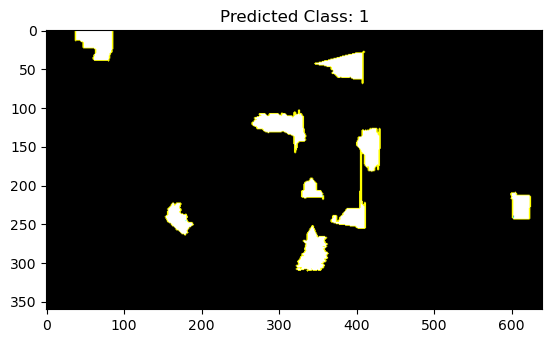

Predicted Class: 1
True Class: 0


In [102]:
import numpy as np
import lime
import lime.lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

visual_logits = np.load('visual_logits_val.npy')
def visual_model_predict(images):
    num_samples = len(images)
    logits = np.tile(visual_logits[0], (num_samples, 1)) 
    predicted_classes = np.argmax(logits, axis=1)
    return logits, predicted_classes

explainer = lime.lime_image.LimeImageExplainer()
logits, predicted_class = visual_model_predict([sample_image])
predicted_class = int(predicted_class[0])

explanation = explainer.explain_instance(
    sample_image,
    lambda x: visual_model_predict(x)[0],  
    top_labels=1, 
    hide_color=0,
    num_samples=1000
)


temp, mask = explanation.get_image_and_mask(
    predicted_class,  
    positive_only=True,
    num_features=10,
    hide_rest=True
)

plt.imshow(mark_boundaries(temp, mask))
plt.title(f"Predicted Class: {predicted_class}")  
plt.show()

print(f"Predicted Class: {predicted_class}")
print(f"True Class: {true_class}")


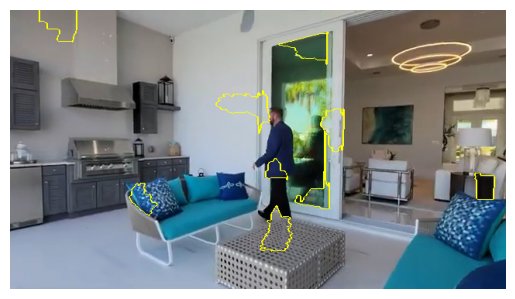

In [104]:
from skimage.segmentation import mark_boundaries

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True, 
    num_features=10, 
    hide_rest=False  
)

plt.imshow(mark_boundaries(temp, mask))
plt.axis('off')
plt.show()
